## Calculative Foundation
- Part A: Vector & Matrix Fundamentals
- Part B: Matrix Operations
- Part C: Linear Transformations & Geometry
- Part D: Eigenvalues & Decomposition


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.figsize'] = (6,4)


In [3]:
data = {
    'Math':       [85, 70, 95, 60, 75],
    'Physics':    [90, 65, 88, 55, 80],
    'Chemistry':  [78, 72, 91, 68, 70]
}
students = ['S1', 'S2', 'S3', 'S4', 'S5']
df = pd.DataFrame(data, index=students)
df


,Math,Physics,Chemistry
S1,85,90,78
S2,70,65,72
S3,95,88,91
S4,60,55,68
S5,75,80,70


## Part A: Vector & Matrix Fundamentals

### A1. Represent each student's subject scores as a vector

In [4]:
vectors = {s: df.loc[s].values.astype(float) for s in students}
for s, v in vectors.items():
    print(f"{s} = {v}")


S1 = [85. 90. 78.]
S2 = [70. 65. 72.]
S3 = [95. 88. 91.]
S4 = [60. 55. 68.]
S5 = [75. 80. 70.]


### A2. Norm-1 and Norm-2 of vectors

- **Norm-1 (Manhattan norm):** |x1| + |x2| + |x3| — sum of absolute values
- **Norm-2 (Euclidean norm):** sqrt(x1² + x2² + x3²) — straight-line magnitude


In [5]:
norm_results = []
for s, v in vectors.items():
    n1 = np.linalg.norm(v, 1)
    n2 = np.linalg.norm(v, 2)
    norm_results.append([s, n1, n2])

norm_df = pd.DataFrame(norm_results, columns=['Student', 'Norm-1', 'Norm-2'])
norm_df


,Student,Norm-1,Norm-2
0,S1,253.0,146.318147
1,S2,207.0,119.620232
2,S3,274.0,158.271918
3,S4,183.0,106.061303
4,S5,225.0,130.096118


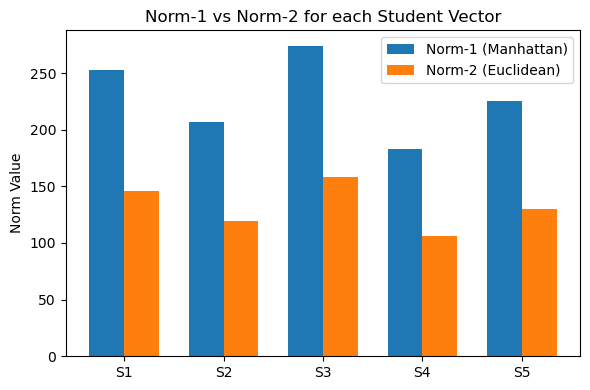

In [6]:
fig, ax = plt.subplots()
x = np.arange(len(students))
width = 0.35
ax.bar(x - width/2, norm_df['Norm-1'], width, label='Norm-1 (Manhattan)')
ax.bar(x + width/2, norm_df['Norm-2'], width, label='Norm-2 (Euclidean)')
ax.set_xticks(x)
ax.set_xticklabels(students)
ax.set_ylabel('Norm Value')
ax.set_title('Norm-1 vs Norm-2 for each Student Vector')
ax.legend()
plt.tight_layout()
plt.show()


### A3. Dot product and angle between two students' score vectors

- **Dot product:** a·b = a1*b1 + a2*b2 + a3*b3
- **Angle:** cos θ = (a·b) / (|a| * |b|), θ = arccos(cos θ)


In [7]:
def dot_and_angle(v1, v2):
    dot = np.dot(v1, v2)
    cos_theta = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
    angle_rad = np.arccos(np.clip(cos_theta, -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)
    return dot, angle_deg

dot12, angle12 = dot_and_angle(vectors['S1'], vectors['S2'])
print(f"S1 . S2 (dot product) = {dot12}")
print(f"Angle between S1 and S2 = {angle12:.2f} degrees")

print("\nAll pairwise dot products & angles:")
for i in range(len(students)):
    for j in range(i+1, len(students)):
        s1, s2 = students[i], students[j]
        d, a = dot_and_angle(vectors[s1], vectors[s2])
        print(f"{s1} & {s2}: dot={d:.1f}, angle={a:.2f} deg")


S1 . S2 (dot product) = 17416.0
Angle between S1 and S2 = 5.70 degrees

All pairwise dot products & angles:
S1 & S2: dot=17416.0, angle=5.70 deg
S1 & S3: dot=23093.0, angle=4.30 deg
S1 & S4: dot=15354.0, angle=8.35 deg
S1 & S5: dot=19035.0, angle=0.38 deg
S2 & S3: dot=18922.0, angle=1.91 deg
S2 & S4: dot=12671.0, angle=2.88 deg
S2 & S5: dot=15490.0, angle=5.52 deg
S3 & S4: dot=16728.0, angle=4.79 deg
S3 & S5: dot=20535.0, angle=4.21 deg
S4 & S5: dot=13660.0, angle=8.11 deg


### A4. Cross product (for 3D selected subjects)

In [8]:
cross_12 = np.cross(vectors['S1'], vectors['S2'])
print(f"S1 x S2 (cross product) = {cross_12}")

cross_34 = np.cross(vectors['S3'], vectors['S4'])
print(f"S3 x S4 (cross product) = {cross_34}")


S1 x S2 (cross product) = [1410. -660. -775.]
S3 x S4 (cross product) = [  979. -1000.   -55.]


### A5. Projection of one vector onto another

Formula: proj_b(a) = ( (a·b) / |b|² ) * b


In [9]:
def projection(a, b):
    scalar = np.dot(a, b) / np.dot(b, b)
    return scalar * b

proj_S1_on_S2 = projection(vectors['S1'], vectors['S2'])
print(f"Projection of S1 onto S2 = {proj_S1_on_S2}")

proj_S3_on_S4 = projection(vectors['S3'], vectors['S4'])
print(f"Projection of S3 onto S4 = {proj_S3_on_S4}")


Projection of S1 onto S2 = [85.2   79.114 87.634]
Projection of S3 onto S4 = [ 89.224  81.789 101.12 ]


## Part B: Matrix Operations

In [10]:
M = df.values.astype(float)
print("Matrix M (Students x Subjects):")
print(M)
print(f"\nShape: {M.shape}")


Matrix M (Students x Subjects):
[[85. 90. 78.]
 [70. 65. 72.]
 [95. 88. 91.]
 [60. 55. 68.]
 [75. 80. 70.]]

Shape: (5, 3)


### B1. Matrix Addition and Multiplication

In [11]:
bonus = np.full(M.shape, 2.0)
M_added = M + bonus
print("\nBonus marks matrix:")
print(bonus)
print("Matrix Addition (M + bonus marks):")
print(M_added)



Bonus marks matrix:
[[2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]
 [2. 2. 2.]]
Matrix Addition (M + bonus marks):
[[87. 92. 80.]
 [72. 67. 74.]
 [97. 90. 93.]
 [62. 57. 70.]
 [77. 82. 72.]]


In [12]:
weights = np.array([[0.4], [0.3], [0.3]])
weighted_scores = M @ weights
print("Weighted Total Scores (M x weights):")
for s, score in zip(students, weighted_scores.flatten()):
    print(f"{s}: {score:.2f}")


Weighted Total Scores (M x weights):
S1: 84.40
S2: 69.10
S3: 91.70
S4: 60.90
S5: 75.00


### B2. Transpose

In [13]:
M_T = M.T
print("Transpose of M (Subjects x Students):")
print(M_T)
print(f"Shape: {M_T.shape}")


Transpose of M (Subjects x Students):
[[85. 70. 95. 60. 75.]
 [90. 65. 88. 55. 80.]
 [78. 72. 91. 68. 70.]]
Shape: (3, 5)


### B3. Inverse

In [14]:
M_square = M[:3, :]
print("Square sub-matrix (3x3):")
print(M_square)

det_val = np.linalg.det(M_square)
print(f"\nDeterminant = {det_val:.2f}")

if abs(det_val) > 1e-6:
    M_inv = np.linalg.inv(M_square)
    print("\nInverse Matrix:")
    print(M_inv)

    identity_check = M_square @ M_inv
    print("\nVerification (M x M_inv = Identity):")
    print(identity_check)
else:
    print("Matrix is singular, inverse does not exist.")


Square sub-matrix (3x3):
[[85. 90. 78.]
 [70. 65. 72.]
 [95. 88. 91.]]

Determinant = 5345.00

Inverse Matrix:
[[-0.079 -0.248  0.264]
 [ 0.088  0.061 -0.123]
 [-0.003  0.2   -0.145]]

Verification (M x M_inv = Identity):
[[ 1.  0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]


## Part C: Linear Transformations & Geometry

### C1. Explain line, plane, and hyperplane with respect to your dataset dimensions.

- **Line (1D):** When considering only **1 subject** (e.g. Math scores), the data can be represented as points on a number line — this is a 1D subspace, or "line".
- **Plane (2D):** When considering **2 subjects** (Math, Physics), each student becomes an (x, y) point — all points lie on a 2D plane.
- **Hyperplane (nD):** When considering **3 or more subjects** (Math, Physics, Chemistry = 3D), the data forms points in 3D space, and a **hyperplane** is a flat (n-1)-dimensional subspace that divides this n-dimensional space into two parts — e.g. in 3D a plane is a hyperplane, and in 2D a line is a hyperplane.

### C2. Dimensionality increase: 2D -> 3D -> higher dimensions

As new subjects (features) are added to the dataset, the dimensionality increases:
- 1 subject → 1D (line)
- 2 subjects → 2D (plane)
- 3 subjects → 3D (space, hyperplane = 2D cutting plane)
- 4+ subjects → higher-dimensional space (cannot be visualized directly, but the vector/matrix operations still work the same way mathematically)

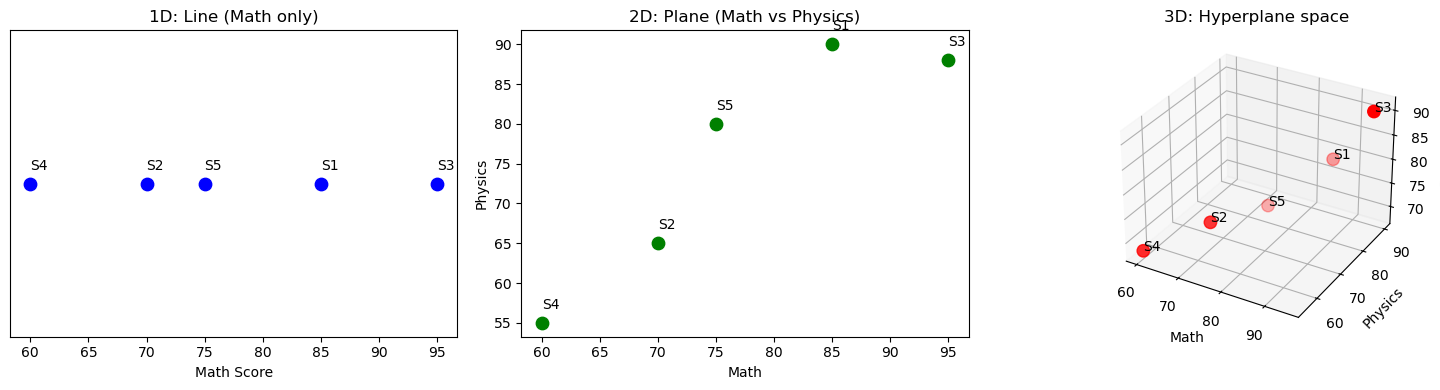

In [ ]:
fig = plt.figure(figsize=(15,4))

math_vals = df['Math'].values
phy_vals = df['Physics'].values
chem_vals = df['Chemistry'].values

ax1 = fig.add_subplot(131)
ax1.scatter(math_vals, np.zeros(len(df)), color='blue', s=80)
for i, s in enumerate(students):
    ax1.annotate(s, (math_vals[i], 0), textcoords="offset points", xytext=(0,10))
ax1.set_title('1D: Line (Math only)')
ax1.set_xlabel('Math Score')
ax1.set_yticks([])

ax2 = fig.add_subplot(132)
ax2.scatter(math_vals, phy_vals, color='green', s=80)
for i, s in enumerate(students):
    ax2.annotate(s, (math_vals[i], phy_vals[i]), textcoords="offset points", xytext=(0,10))
ax2.set_title('2D: Plane (Math vs Physics)')
ax2.set_xlabel('Math')
ax2.set_ylabel('Physics')

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(math_vals, phy_vals, chem_vals, color='red', s=80)
for i, s in enumerate(students):
    ax3.text(math_vals[i], phy_vals[i], chem_vals[i], s)
ax3.set_title('3D: Hyperplane space')
ax3.set_xlabel('Math')
ax3.set_ylabel('Physics')
ax3.set_zlabel('Chemistry')

plt.tight_layout()
plt.show()



## Part D: Eigenvalues & Decomposition

### D1. Compute eigenvalues and eigenvectors of the covariance matrix

In [ ]:
scaler = StandardScaler()
M_scaled = scaler.fit_transform(M)
print("Standardized Data:")
print(M_scaled)


Standardized Data:
[[ 0.662  1.063  0.265]
 [-0.579 -0.783 -0.458]
 [ 1.49   0.916  1.83 ]
 [-1.407 -1.521 -0.939]
 [-0.166  0.325 -0.698]]


In [ ]:
cov_matrix = np.cov(M_scaled.T)
print("Covariance Matrix (3x3, Subject-wise):")
print(cov_matrix)


Covariance Matrix (3x3, Subject-wise):
[[1.25  1.152 1.151]
 [1.152 1.25  0.879]
 [1.151 0.879 1.25 ]]


In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors (each column is an eigenvector):")
print(eigenvectors)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

print("\nSorted Eigenvalues (descending):")
print(eigenvalues_sorted)

explained_var = eigenvalues_sorted / eigenvalues_sorted.sum() * 100
print("\nExplained Variance % by each Principal Component:")
for i, ev in enumerate(explained_var):
    print(f"PC{i+1}: {ev:.2f}%")


Eigenvalues:
[3.376 0.003 0.371]

Eigenvectors (each column is an eigenvector):
[[ 0.608  0.794 -0.001]
 [ 0.561 -0.431 -0.707]
 [ 0.561 -0.429  0.708]]

Sorted Eigenvalues (descending):
[3.376 0.371 0.003]

Explained Variance % by each Principal Component:
PC1: 90.04%
PC2: 9.88%
PC3: 0.08%


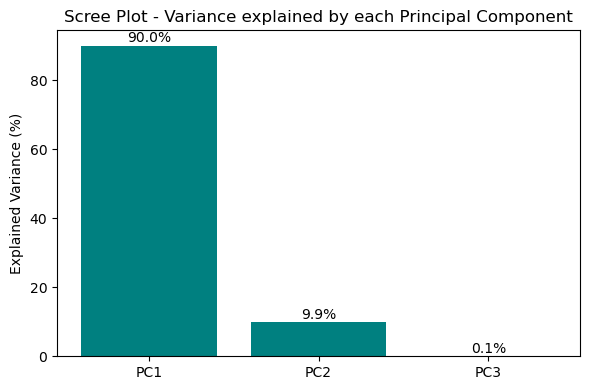

In [ ]:
fig, ax = plt.subplots()
pcs = [f'PC{i+1}' for i in range(len(explained_var))]
ax.bar(pcs, explained_var, color='teal')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot - Variance explained by each Principal Component')
for i, v in enumerate(explained_var):
    ax.text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()
